
# FEVER Evaluation Report

This notebook:
- Loads results from **Originality.ai fact checker** and **GPT models** (closed-book by default).
- Computes **accuracy, precision, recall, F1**, and **macro-F1** for binary labels (`true`/`false`).
- Plots a **bar chart** for metrics across models (each metric = separate plot).
- Renders a **confusion matrix** figure for each model (own plot per model).
- Shows a **full results table**.

**Expected input files** (put in the same folder as this notebook):
- `checker_results.jsonl`
- `gpt_results_raw_gpt-4o.jsonl`
- `gpt_results_raw_gpt-5.jsonl`

If a file is missing, the cell will skip that model and continue.


In [22]:

import os, json, re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# File paths (edit these if yours are different)
CHECKER_FILE = Path("checker_results.jsonl")
GPT4O_FILE   = Path("gpt_results_raw_gpt-4o.jsonl")
GPT5_FILE    = Path("gpt_results_raw_gpt-5.jsonl")

# If you also ran 'with web search', you can add more files below (same format).
# Example:
# GPT4O_SEARCH_FILE = Path("gpt_results_raw_gpt-4o.search.jsonl")
# GPT5_SEARCH_FILE  = Path("gpt_results_raw_gpt-5.search.jsonl")


In [23]:

def read_jsonl(path: Path):
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if not s: 
                continue
            try:
                yield json.loads(s)
            except Exception:
                continue

def norm(lbl):
    if lbl is None: 
        return None
    s = str(lbl).strip().lower()
    if s in {"true","supports","supported"}: 
        return "true"
    if s in {"false","refutes","refuted"}:   
        return "false"
    return None

# --- Prediction extractors ---

def get_checker_pred(obj: dict):
    """Extracts the checker prediction from nested JSON response."""
    try:
        r0 = obj["checker_response"]["data"]["results"][0]
        return norm(r0.get("classification"))
    except Exception:
        return None

# For GPT text extraction
LABEL_LINE = re.compile(r'\b(label|verdict|decision)\s*[:\-]\s*(true|false)\b', re.I)
FIRST_TF   = re.compile(r'\b(true|false)\b', re.I)

def get_gpt_pred_text(txt: str):
    if not txt: 
        return None
    m = LABEL_LINE.search(txt)
    if m: 
        return m.group(2).lower()
    head = " ".join(txt.split()[:20])
    m = FIRST_TF.search(head)
    return m.group(1).lower() if m else None

# --- Metrics / confusion ---

def prf1(tp, fp, fn):
    p = tp/(tp+fp) if (tp+fp) else 0.0
    r = tp/(tp+fn) if (tp+fn) else 0.0
    f1 = (2*p*r)/(p+r) if (p+r) else 0.0
    return p, r, f1

def eval_file(tag: str, path: Path, kind: str):
    """Evaluate a single model file.
    kind: 'checker' or 'gpt'
    Returns: dict with metrics + confusion matrix
    """
    if not path.exists():
        return None  # skip
    
    cm = [[0,0],[0,0]]  # rows gold(true,false) x cols pred(true,false)
    total = evaluated = skipped = 0

    for obj in read_jsonl(path):
        total += 1
        gold = norm(obj.get("gold"))
        if gold not in {"true","false"}:
            skipped += 1
            continue
        
        if kind == "checker":
            pred = get_checker_pred(obj)
        else:
            if obj.get("status") != "ok":
                skipped += 1
                continue
            pred = norm(get_gpt_pred_text(obj.get("response_text","")))

        if pred not in {"true","false"}:
            skipped += 1
            continue

        evaluated += 1
        gi = 0 if gold == "true" else 1
        pi = 0 if pred == "true" else 1
        cm[gi][pi] += 1

    # metrics from cm
    TP_t, FN_t = cm[0][0], cm[0][1]
    FP_t, TN_t = cm[1][0], cm[1][1]
    TP_f, FN_f = TN_t, FP_t
    FP_f, TN_f = FN_t, TP_t

    acc = (TP_t + TN_t) / evaluated if evaluated else 0.0
    p_t, r_t, f1_t = prf1(TP_t, FP_t, FN_t)
    p_f, r_f, f1_f = prf1(TP_f, FP_f, FN_f)
    macro_f1 = (f1_t + f1_f) / 2 if evaluated else 0.0

    return {
        "model": tag,
        "evaluated": evaluated,
        "skipped": skipped,
        "accuracy": acc,
        "TP_t": TP_t,
        "TN_t": TN_t,
        "FP_t": FP_t,
        "FN_t": FN_t,
        "precision_true": p_t,
        "recall_true": r_t,
        "f1_true": f1_t,
        "precision_false": p_f,
        "recall_false": r_f,
        "f1_false": f1_f,
        "macro_f1": macro_f1,
        "cm": cm,
    }

def cm_to_dataframe(cm):
    import pandas as pd
    return pd.DataFrame(cm, index=["gold:true","gold:false"], columns=["pred:true","pred:false"])


In [24]:

evaluations = []

res_checker = eval_file("Originality.ai", CHECKER_FILE, "checker")
if res_checker: evaluations.append(res_checker)

res_gpt4o = eval_file("GPT-4o", GPT4O_FILE, "gpt")
if res_gpt4o: evaluations.append(res_gpt4o)

res_gpt5 = eval_file("GPT-5", GPT5_FILE, "gpt")
if res_gpt5: evaluations.append(res_gpt5)

if not evaluations:
    print("No result files found. Please place JSONL outputs next to this notebook and re-run.")
else:
    print(f"Loaded {len(evaluations)} model(s).")


Loaded 3 model(s).


In [38]:

if evaluations:
    df = pd.DataFrame([{
        "Model": e["model"],
        "Evaluated": e["evaluated"],
        "Skipped": e["skipped"],
        "Accuracy": e["accuracy"],
        "Precision": e["precision_true"],
        "Recall": e["recall_true"],
        "F1": e["f1_true"],
        "TP": f'{e["TP_t"]} ({e["TP_t"] / e["evaluated"]:.3f}%)',
        "TN": f'{e["TN_t"]} ({e["TN_t"] / e["evaluated"]:.3f}%)',
        "FP": f'{e["FP_t"]} ({e["FP_t"] / e["evaluated"]:.3f}%)',
        "FN": f'{e["FN_t"]} ({e["FN_t"] / e["evaluated"]:.3f}%)',
        # "Macro-F1": e["macro_f1"],
        # "Prec(false)": e["precision_false"],
        # "Rec(false)": e["recall_false"],
        # "F1(false)": e["f1_false"],
    } for e in evaluations]).sort_values("Accuracy", ascending=False).reset_index(drop=True)
    display(df.round(3))
else:
    print("No evaluations to display.")


,Model,Evaluated,Skipped,Accuracy,Precision,Recall,F1,TP,TN,FP,FN
0,GPT-5,1000,0,0.916,0.937,0.892,0.914,446 (0.446%),470 (0.470%),30 (0.030%),54 (0.054%)
1,Originality.ai,972,28,0.904,0.918,0.890,0.904,438 (0.451%),441 (0.454%),39 (0.040%),54 (0.056%)
2,GPT-4o,999,1,0.874,0.868,0.882,0.875,440 (0.440%),433 (0.433%),67 (0.067%),59 (0.059%)


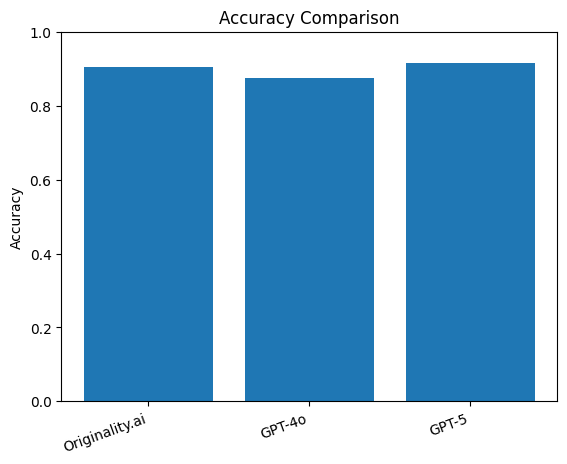

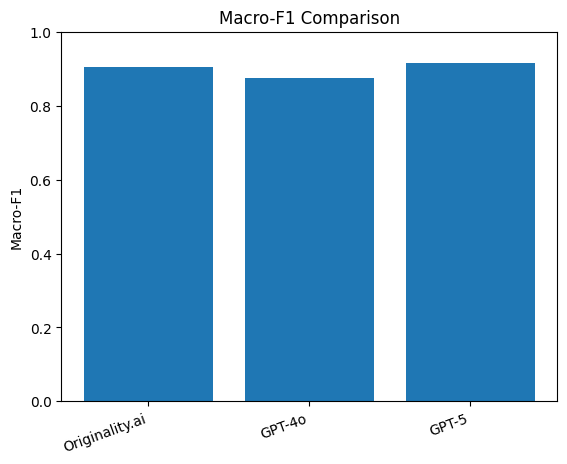

In [26]:

if evaluations:
    import numpy as np

    # Accuracy bar
    labels = [e["model"] for e in evaluations]
    accs   = [e["accuracy"] for e in evaluations]

    plt.figure()
    plt.bar(labels, accs)
    plt.ylabel("Accuracy")
    plt.title("Accuracy Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.ylim(0, 1.0)
    plt.show()

    # Macro-F1 bar
    mf1 = [e["macro_f1"] for e in evaluations]

    plt.figure()
    plt.bar(labels, mf1)
    plt.ylabel("Macro-F1")
    plt.title("Macro-F1 Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.ylim(0, 1.0)
    plt.show()
else:
    print("No evaluations for plots.")


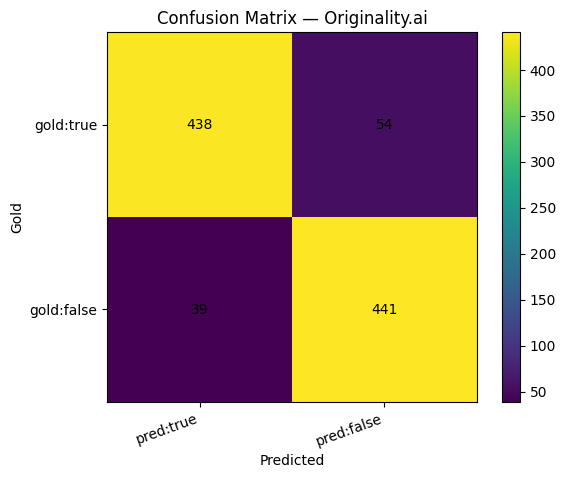

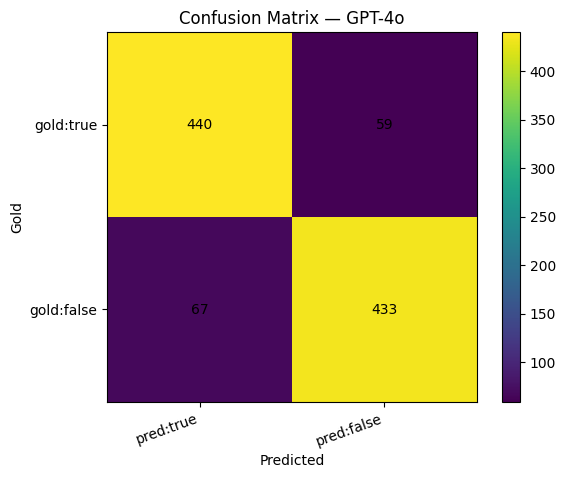

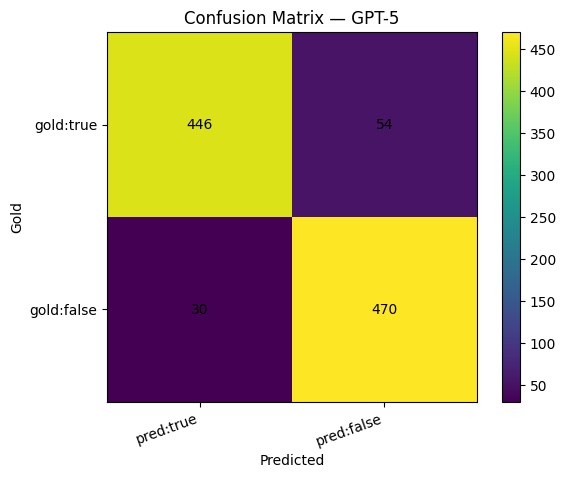

In [27]:

if evaluations:
    for e in evaluations:
        cm = e["cm"]
        df_cm = cm_to_dataframe(cm)

        plt.figure()
        plt.imshow(df_cm.values, aspect="equal")
        plt.title(f"Confusion Matrix — {e['model']}")
        plt.xlabel("Predicted")
        plt.ylabel("Gold")
        # tick labels
        plt.xticks([0,1], df_cm.columns.tolist(), rotation=20, ha="right")
        plt.yticks([0,1], df_cm.index.tolist())
        # annotate counts
        for i in range(df_cm.shape[0]):
            for j in range(df_cm.shape[1]):
                plt.text(j, i, str(df_cm.values[i, j]), ha="center", va="center")
        plt.colorbar()
        plt.show()
else:
    print("No evaluations for confusion matrices.")


In [28]:

if evaluations:
    out_csv = Path("fever_eval_summary.csv")
    df = pd.DataFrame([{
        "Model": e["model"],
        "Evaluated": e["evaluated"],
        "Skipped": e["skipped"],
        "Accuracy": e["accuracy"],
        "Macro-F1": e["macro_f1"],
        "Prec(true)": e["precision_true"],
        "Rec(true)": e["recall_true"],
        "F1(true)": e["f1_true"],
        "Prec(false)": e["precision_false"],
        "Rec(false)": e["recall_false"],
        "F1(false)": e["f1_false"],
    } for e in evaluations])
    df.to_csv(out_csv, index=False)
    print(f"Saved summary -> {out_csv.resolve()}")
else:
    print("No evaluations to save.")


Saved summary -> /Users/rustemkakimov/Code/MITACS/ouroboros/ai_slop_study/fever_eval_summary.csv
